In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### Q1 - Outlier Detection using the Percentile Method

In [74]:
# Generated skewed data

np.random.seed(9009)
data = np.random.exponential(100000,1000)
df = pd.DataFrame({
    'Salary': data,
})
df.head()

,Salary
0,270853.225173
1,8220.783507
2,152398.096813
3,161815.368605
4,4981.101376


In [75]:
# Added 5 extreme values

df.loc[np.random.choice(df.index, 5),'Salary'] = [10000000, 50000000, 190000000, 76000000, 20030000]

In [76]:
# Percentiles

lower = df['Salary'].quantile(0.01)
upper = df['Salary'].quantile(0.99)

print(f'Normal Range: {lower} to {upper}')

Normal Range: 980.6702926356444 to 546360.1615015764


In [77]:
# Remove values

mask = ((df['Salary'] < lower) | (df['Salary'] > upper))
df_clean = df[~mask].copy()
df_clean

,Salary
0,270853.225173
1,8220.783507
2,152398.096813
3,161815.368605
4,4981.101376
...,...
995,25188.710590
996,73285.668140
997,100641.516261
998,546205.879475


In [78]:
df

,Salary
0,270853.225173
1,8220.783507
2,152398.096813
3,161815.368605
4,4981.101376
...,...
995,25188.710590
996,73285.668140
997,100641.516261
998,546205.879475


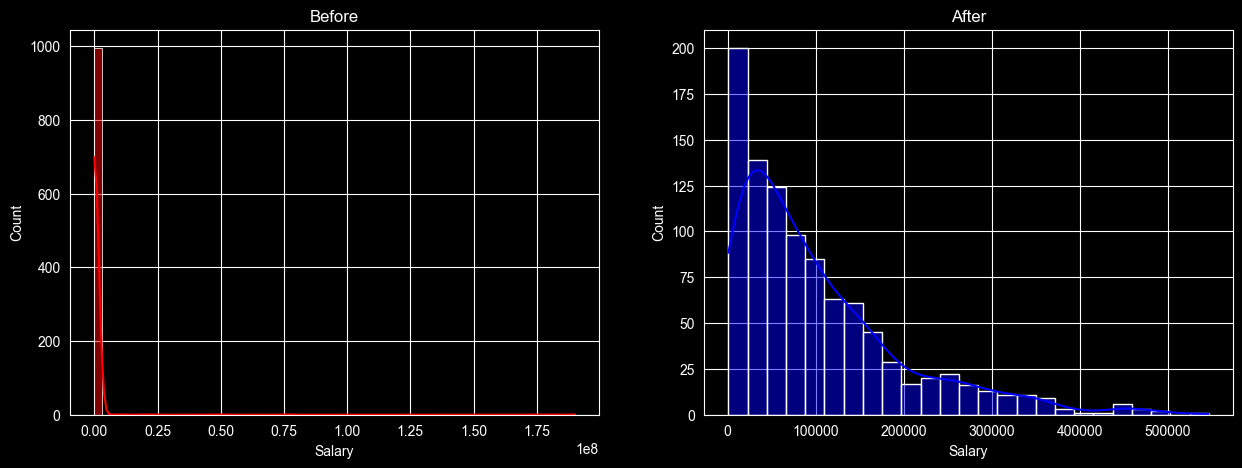

In [81]:
# Before vs After

fig, axes = plt.subplots(1,2,figsize=(15,5))

sns.histplot(data=df , x='Salary', ax=axes[0], color='red',kde=True)
axes[0].set_title('Before')
# axes[0].set_xlim(0,600000)

sns.histplot(data=df_clean , x='Salary', ax=axes[1], color='blue', kde=True)
axes[1].set_title('After')

plt.show()